In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
X_Train_Drugs = pd.read_csv("DrugTesting.csv", usecols = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"])
Y_Train_Drugs = pd.read_csv("DrugTesting.csv", usecols = ["Drug"])
X_Train_CarSeats = pd.read_csv("CarSeats.csv", usecols = ["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "ShelveLoc", "Age", "Education"])
Y_Train_CarSeats = pd.read_csv("CarSeats.csv", usecols = ["Urban"])
X_Train_Drugs = X_Train_Drugs.to_numpy()
Y_Train_Drugs = Y_Train_Drugs.to_numpy()
X_Train_CarSeats = X_Train_CarSeats.to_numpy()
Y_Train_CarSeats = Y_Train_CarSeats.to_numpy()

In [87]:
for i in range(X_Train_Drugs.shape[0]):
    if X_Train_Drugs[i][1] == "F":
        X_Train_Drugs[i][1] = 0
    elif X_Train_Drugs[i][1] == "M":
        X_Train_Drugs[i][1] = 1
    if X_Train_Drugs[i][2] == "LOW":
        X_Train_Drugs[i][2] = 0
    elif X_Train_Drugs[i][2] == "NORMAL":
        X_Train_Drugs[i][2] = 1
    elif X_Train_Drugs[i][2] == "HIGH":
        X_Train_Drugs[i][2] = 2
    if X_Train_Drugs[i][3] == "NORMAL":
        X_Train_Drugs[i][3] = 0
    elif X_Train_Drugs[i][3] == "HIGH":
        X_Train_Drugs[i][3] = 1
    if Y_Train_Drugs[i][0] == "drugA":
        Y_Train_Drugs[i][0] = 0
    elif Y_Train_Drugs[i][0] == "drugB":
        Y_Train_Drugs[i][0] = 1
    elif Y_Train_Drugs[i][0] == "drugC":
        Y_Train_Drugs[i][0] = 2
    elif Y_Train_Drugs[i][0] == "drugX":
        Y_Train_Drugs[i][0] = 3
    elif Y_Train_Drugs[i][0] == "drugY":
        Y_Train_Drugs[i][0] = 4

In [88]:
print(X_Train_Drugs, Y_Train_Drugs)

[[23 0 2 1 25.355]
 [47 1 0 1 13.093]
 [47 1 0 1 10.114]
 [28 0 1 1 7.798]
 [61 0 0 1 18.043]
 [22 0 1 1 8.607]
 [49 0 1 1 16.275]
 [41 1 0 1 11.037]
 [60 1 1 1 15.171]
 [43 1 0 0 19.368]
 [47 0 0 1 11.767]
 [34 0 2 0 19.199]
 [43 1 0 1 15.376]
 [74 0 0 1 20.942]
 [50 0 1 1 12.703]
 [16 0 2 0 15.516]
 [69 1 0 0 11.455]
 [43 1 2 1 13.972]
 [23 1 0 1 7.298]
 [32 0 2 0 25.974]
 [57 1 0 0 19.128]
 [63 1 1 1 25.917]
 [47 1 0 0 30.568]
 [48 0 0 1 15.036]
 [33 0 0 1 33.486]
 [28 0 2 0 18.809]
 [31 1 2 1 30.366]
 [49 0 1 0 9.381]
 [39 0 0 0 22.697]
 [45 1 0 1 17.951]
 [18 0 1 0 8.75]
 [74 1 2 1 9.567]
 [49 1 0 0 11.014]
 [65 0 2 0 31.876]
 [53 1 1 1 14.133]
 [46 1 1 0 7.285]
 [32 1 2 0 9.445]
 [39 1 0 0 13.938]
 [39 0 1 0 9.709]
 [15 1 1 1 9.084]
 [73 0 1 1 19.221]
 [58 0 2 0 14.239]
 [50 1 1 0 15.79]
 [23 1 1 1 12.26]
 [50 0 1 0 12.295]
 [66 0 1 0 8.107]
 [37 0 2 1 13.091]
 [68 1 0 1 10.291]
 [23 1 1 1 31.686]
 [28 0 0 1 19.796]
 [58 0 2 1 19.416]
 [67 1 1 0 10.898]
 [62 1 0 0 27.183]
 [24 0 

In [89]:
print(X_Train_CarSeats, Y_Train_CarSeats)

[[  9.5  138.    73.   ...   0.    42.    17.  ]
 [ 11.22 111.    48.   ...   2.    65.    10.  ]
 [ 10.06 113.    35.   ...   1.    59.    12.  ]
 ...
 [  7.41 162.    26.   ...   1.    40.    18.  ]
 [  5.94 100.    79.   ...   0.    50.    12.  ]
 [  9.71 134.    37.   ...   2.    49.    16.  ]] [[1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]


In [90]:
X_Train_Drugs, X_Test_Drugs, Y_Train_Drugs, Y_Test_Drugs = train_test_split(X_Train_Drugs, Y_Train_Drugs, stratify = Y_Train_Drugs)
X_Train_CarSeats, X_Test_CarSeats, Y_Train_CarSeats, Y_Test_CarSeats = train_test_split(X_Train_CarSeats, Y_Train_CarSeats, stratify = Y_Train_CarSeats)

In [14]:
print(X_Train_Drugs.shape, Y_Train_Drugs.shape, X_Test_Drugs.shape, Y_Test_Drugs.shape)
Y_Train_Drugs = Y_Train_Drugs.astype("int")
Y_Test_Drugs = Y_Test_Drugs.astype("int")

(150, 5) (150, 1) (50, 5) (50, 1)


In [15]:
print(X_Train_CarSeats.shape, Y_Train_CarSeats.shape, X_Test_CarSeats.shape, Y_Test_CarSeats.shape)
Y_Train_CarSeats = Y_Train_CarSeats.astype("int")
Y_Test_CarSeats = Y_Test_CarSeats.astype("int")

(300, 9) (300, 1) (100, 9) (100, 1)


In [16]:
dTree_Drugs = tree.DecisionTreeClassifier(random_state = 0)
dTree_Drugs.fit(X_Train_Drugs, Y_Train_Drugs)
Y_Train_Pred_Drugs = dTree_Drugs.predict(X_Train_Drugs)
Y_Test_Pred_Drugs = dTree_Drugs.predict(X_Test_Drugs)

In [17]:
dTree_CarSeats = tree.DecisionTreeClassifier(random_state = 0)
dTree_CarSeats.fit(X_Train_CarSeats, Y_Train_CarSeats)
Y_Train_Pred_CarSeats = dTree_CarSeats.predict(X_Train_CarSeats)
Y_Test_Pred_CarSeats = dTree_CarSeats.predict(X_Test_CarSeats)

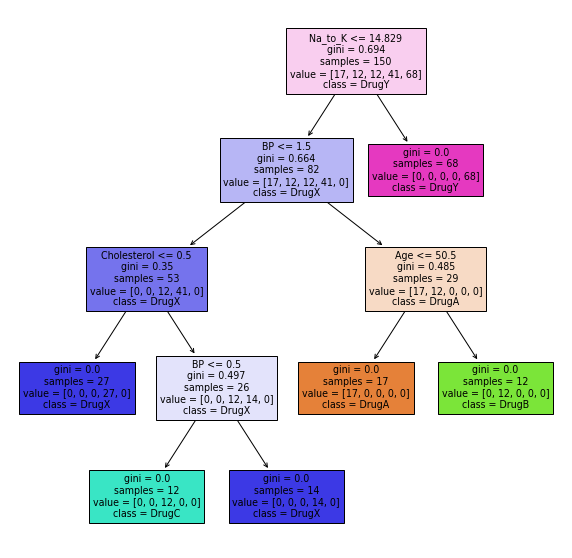

In [18]:
plt.figure(figsize = (10, 10))
features = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]
classes = ["DrugA", "DrugB", "DrugC", "DrugX", "DrugY",]
tree.plot_tree(dTree_Drugs, feature_names = features, class_names = classes, filled = True)
plt.show()

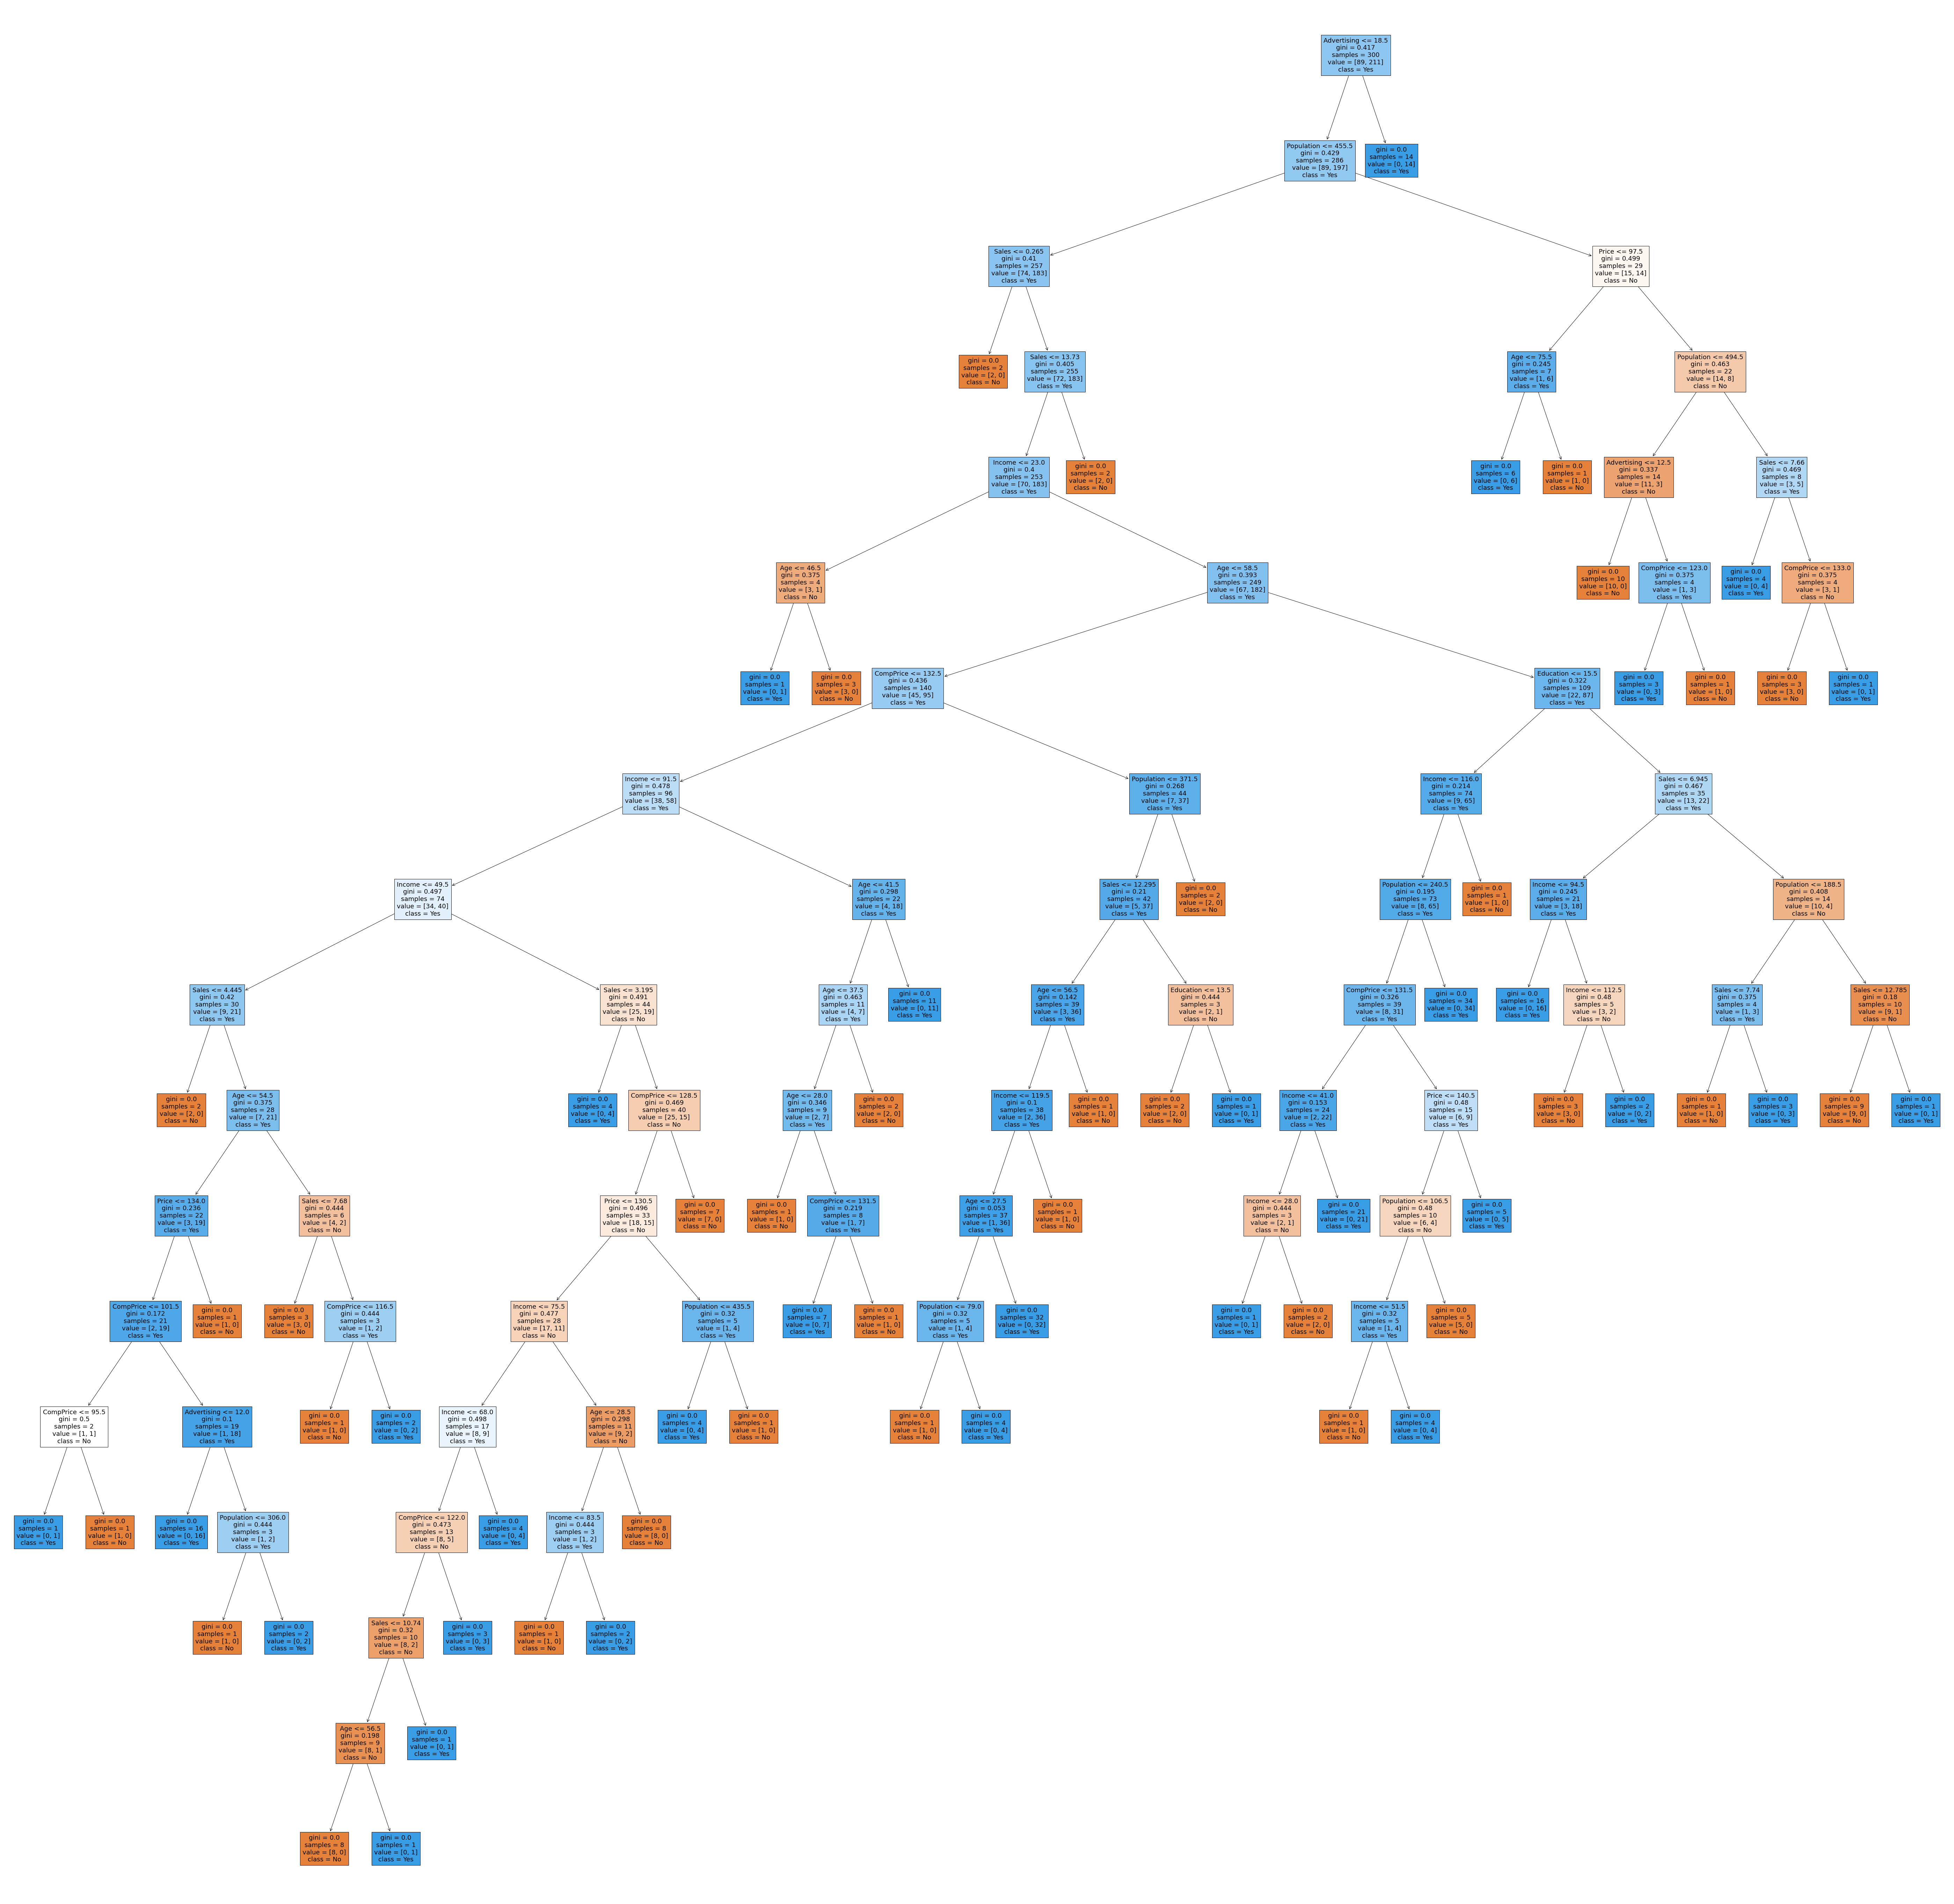

In [22]:
plt.figure(figsize = (100, 100))
features = ["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "ShelveLoc", "Age", "Education"]
classes = ["No", "Yes"]
tree.plot_tree(dTree_CarSeats, feature_names = features, class_names = classes, filled = True)
plt.show()

In [23]:
print("Train Accuracy", accuracy_score(Y_Train_Pred_Drugs, Y_Train_Drugs) * 100, "%")
print("Test Accuracy", accuracy_score(Y_Test_Pred_Drugs, Y_Test_Drugs) * 100, "%")

Train Accuracy 100.0 %
Test Accuracy 100.0 %


In [24]:
print("Train Accuracy", accuracy_score(Y_Train_Pred_CarSeats, Y_Train_CarSeats) * 100, "%")
print("Test Accuracy", accuracy_score(Y_Test_Pred_CarSeats, Y_Test_CarSeats) * 100, "%")

Train Accuracy 100.0 %
Test Accuracy 63.0 %


In [25]:
#Since Test Accuracy for CarSeats Decision Tree is very less than Training so we need to apply Pruning and see the results

In [46]:
params = {'max_depth' : [2, 4, 6, 8, 10, 12],
         'min_samples_split' : [2, 3, 4],
         'min_samples_leaf' : [1, 2]}

Tree_CarSeats_PrePruned = tree.DecisionTreeClassifier()
gcv = GridSearchCV(estimator = Tree_CarSeats_PrePruned, param_grid = params)
gcv.fit(X_Train_CarSeats, Y_Train_CarSeats)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 12],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3, 4]})

In [47]:
dTree_CarSeats_PrePruned = gcv.best_estimator_
dTree_CarSeats_PrePruned.fit(X_Train_CarSeats, Y_Train_CarSeats)
Y_Train_Pred_CarSeats_PrePruned = dTree_CarSeats_PrePruned.predict(X_Train_CarSeats)
Y_Test_Pred_CarSeats_PrePruned = dTree_CarSeats_PrePruned.predict(X_Test_CarSeats)

In [48]:
print("Train Accuracy", accuracy_score(Y_Train_Pred_CarSeats_PrePruned, Y_Train_CarSeats) * 100, "%")
print("Test Accuracy", accuracy_score(Y_Test_Pred_CarSeats_PrePruned, Y_Test_CarSeats) * 100, "%")

Train Accuracy 74.66666666666667 %
Test Accuracy 68.0 %


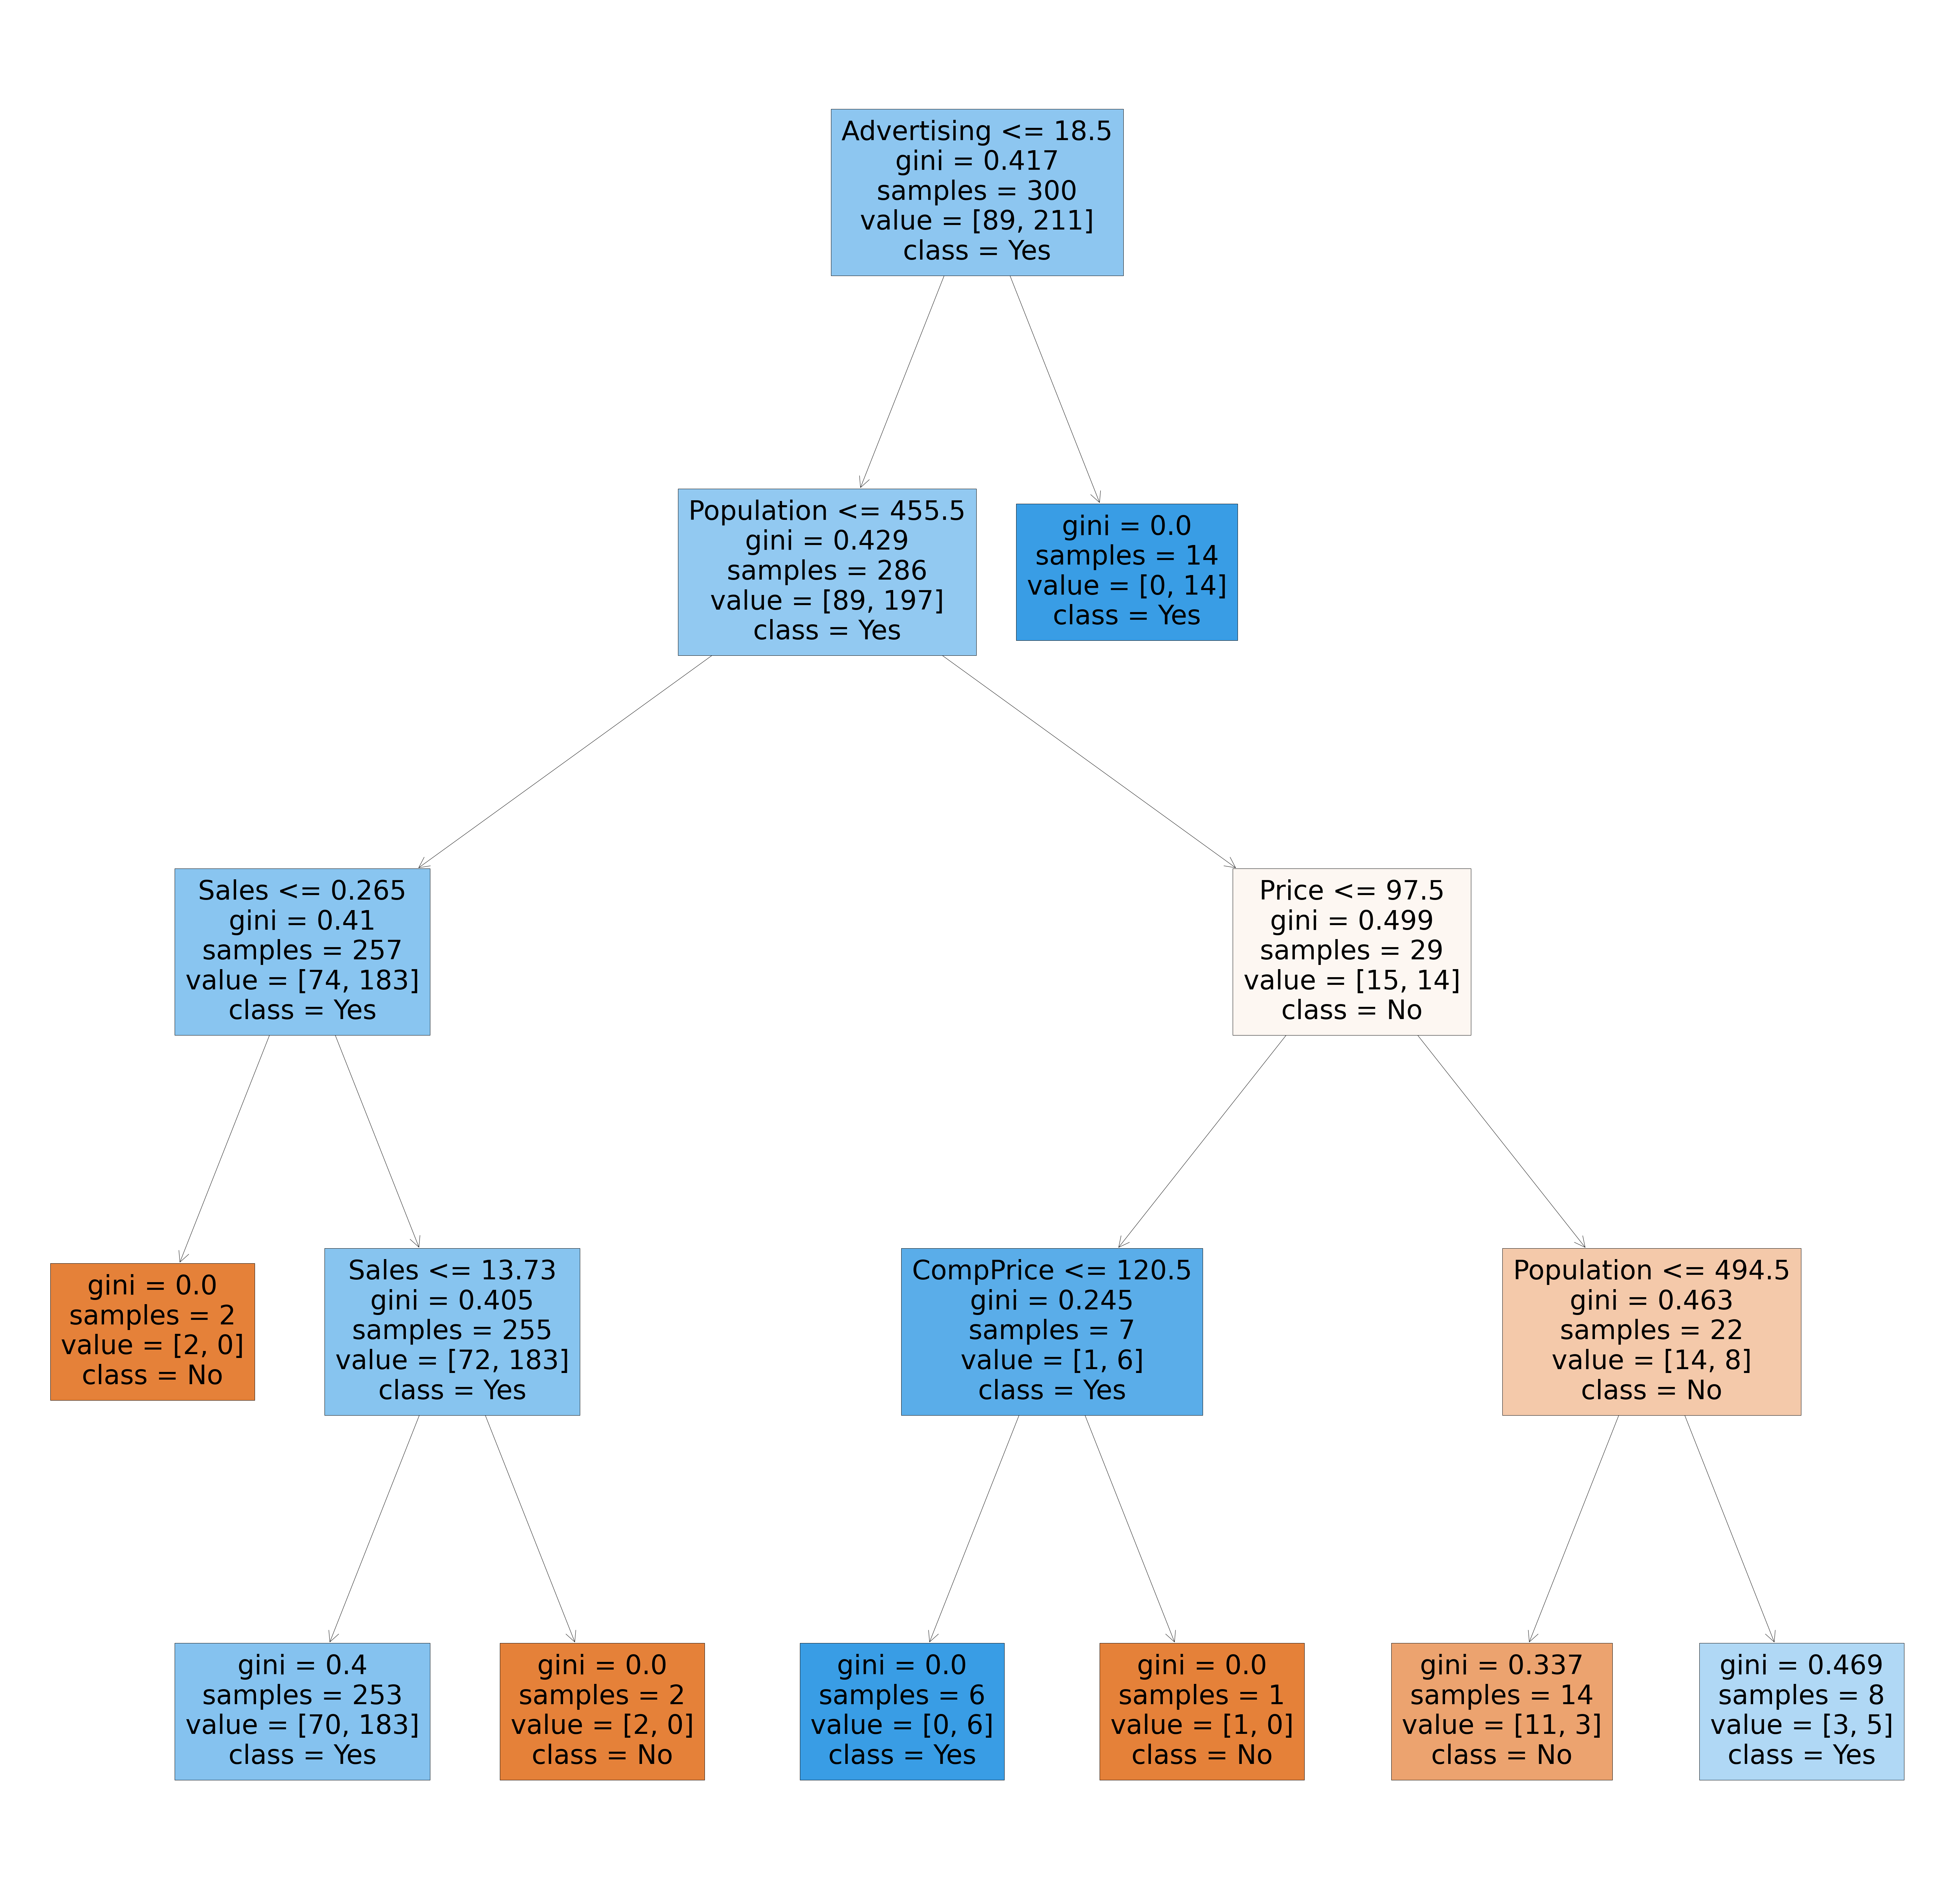

In [49]:
plt.figure(figsize = (100, 100))
features = ["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "ShelveLoc", "Age", "Education"]
classes = ["No", "Yes"]
tree.plot_tree(dTree_CarSeats_PrePruned, feature_names = features, class_names = classes, filled = True)
plt.show()

In [76]:
params = {'max_depth' : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
         'min_samples_split' : [4, 5, 6, 7, 8, 9, 10],
         'min_samples_leaf' : [3, 4, 5, 6, 7]}

Tree_CarSeats_PrePruned = tree.DecisionTreeClassifier()
gcv = GridSearchCV(estimator = Tree_CarSeats_PrePruned, param_grid = params)
gcv.fit(X_Train_CarSeats, Y_Train_CarSeats)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [3, 4, 5, 6, 7],
                         'min_samples_split': [4, 5, 6, 7, 8, 9, 10]})

In [77]:
dTree_CarSeats_PrePruned = gcv.best_estimator_
dTree_CarSeats_PrePruned.fit(X_Train_CarSeats, Y_Train_CarSeats)
Y_Train_Pred_CarSeats_PrePruned = dTree_CarSeats_PrePruned.predict(X_Train_CarSeats)
Y_Test_Pred_CarSeats_PrePruned = dTree_CarSeats_PrePruned.predict(X_Test_CarSeats)

In [78]:
print("Train Accuracy", accuracy_score(Y_Train_Pred_CarSeats_PrePruned, Y_Train_CarSeats) * 100, "%")
print("Test Accuracy", accuracy_score(Y_Test_Pred_CarSeats_PrePruned, Y_Test_CarSeats) * 100, "%")

Train Accuracy 73.66666666666667 %
Test Accuracy 70.0 %


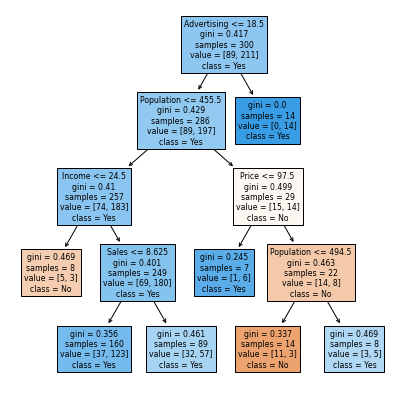

In [79]:
plt.figure(figsize = (7, 7))
features = ["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "ShelveLoc", "Age", "Education"]
classes = ["No", "Yes"]
tree.plot_tree(dTree_CarSeats_PrePruned, feature_names = features, class_names = classes, filled = True)
plt.show()

In [30]:
#Post Pruning using Cost Complexity Pruning

In [31]:
path = dTree_CarSeats.cost_complexity_pruning_path(X_Train_CarSeats, Y_Train_CarSeats)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print(ccp_alphas)

[0.         0.00301587 0.00324324 0.00444444 0.00444444 0.00444444
 0.00444444 0.005      0.005      0.005      0.005      0.00518519
 0.00520924 0.00533333 0.00533333 0.00533333 0.00571429 0.00572391
 0.00598753 0.006      0.0064591  0.00646465 0.00690909 0.00715415
 0.0075     0.00791919 0.00795455 0.008      0.00804762 0.0082197
 0.00862218 0.00891246 0.00914286 0.00927214]


In [32]:
dTrees_CarSeats_PostPruned = []
for ccp_alpha in ccp_alphas:
    dTree_CarSeats_PostPruned = tree.DecisionTreeClassifier(random_state = 0, ccp_alpha = ccp_alpha)
    dTree_CarSeats_PostPruned.fit(X_Train_CarSeats, Y_Train_CarSeats)
    dTrees_CarSeats_PostPruned.append(dTree_CarSeats_PostPruned)

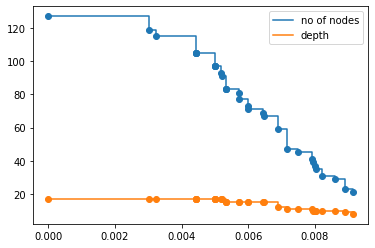

In [33]:
dTrees_CarSeats_PostPruned = dTrees_CarSeats_PostPruned[:-1]
ccp_alphas = ccp_alphas[:-1]
node_counts = [dTree_CarSeats_PostPruned.tree_.node_count for dTree_CarSeats_PostPruned in dTrees_CarSeats_PostPruned]
depth = [dTree_CarSeats_PostPruned.tree_.max_depth for dTree_CarSeats_PostPruned in dTrees_CarSeats_PostPruned]
plt.scatter(ccp_alphas, node_counts)
plt.scatter(ccp_alphas, depth)
plt.plot(ccp_alphas, node_counts, label = 'no of nodes', drawstyle = "steps-post")
plt.plot(ccp_alphas, depth, label = 'depth', drawstyle = "steps-post")
plt.legend()
plt.show()

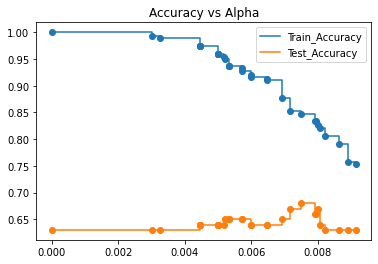

In [34]:
Train_Accuracies = []
Test_Accuracies = []
for dTree_PostPruned in dTrees_CarSeats_PostPruned:
    Y_Train_Pred_CarSeats_PostPruned = dTree_PostPruned.predict(X_Train_CarSeats)
    Y_Test_Pred_CarSeats_PostPruned = dTree_PostPruned.predict(X_Test_CarSeats)
    Train_Accuracies.append(accuracy_score(Y_Train_Pred_CarSeats_PostPruned, Y_Train_CarSeats))
    Test_Accuracies.append(accuracy_score(Y_Test_Pred_CarSeats_PostPruned, Y_Test_CarSeats))

plt.scatter(ccp_alphas, Train_Accuracies)
plt.scatter(ccp_alphas, Test_Accuracies)
plt.plot(ccp_alphas, Train_Accuracies, label = 'Train_Accuracy', drawstyle = "steps-post")
plt.plot(ccp_alphas, Test_Accuracies, label = 'Test_Accuracy', drawstyle = "steps-post")
plt.legend()
plt.title('Accuracy vs Alpha')
plt.show()

In [39]:
dTree_CarSeats_PostPruned_Alpha = tree.DecisionTreeClassifier(random_state = 0, ccp_alpha = 0.0075)
dTree_CarSeats_PostPruned_Alpha.fit(X_Train_CarSeats, Y_Train_CarSeats)
Y_Train_Pred_CarSeats_PostPruned_Alpha = dTree_CarSeats_PostPruned_Alpha.predict(X_Train_CarSeats)
Y_Test_Pred_CarSeats_PostPruned_Alpha = dTree_CarSeats_PostPruned_Alpha.predict(X_Test_CarSeats)

In [40]:
print("Train Accuracy", accuracy_score(Y_Train_Pred_CarSeats_PostPruned_Alpha, Y_Train_CarSeats) * 100, "%")
print("Test Accuracy", accuracy_score(Y_Test_Pred_CarSeats_PostPruned_Alpha, Y_Test_CarSeats) * 100, "%")

Train Accuracy 85.33333333333334 %
Test Accuracy 67.0 %


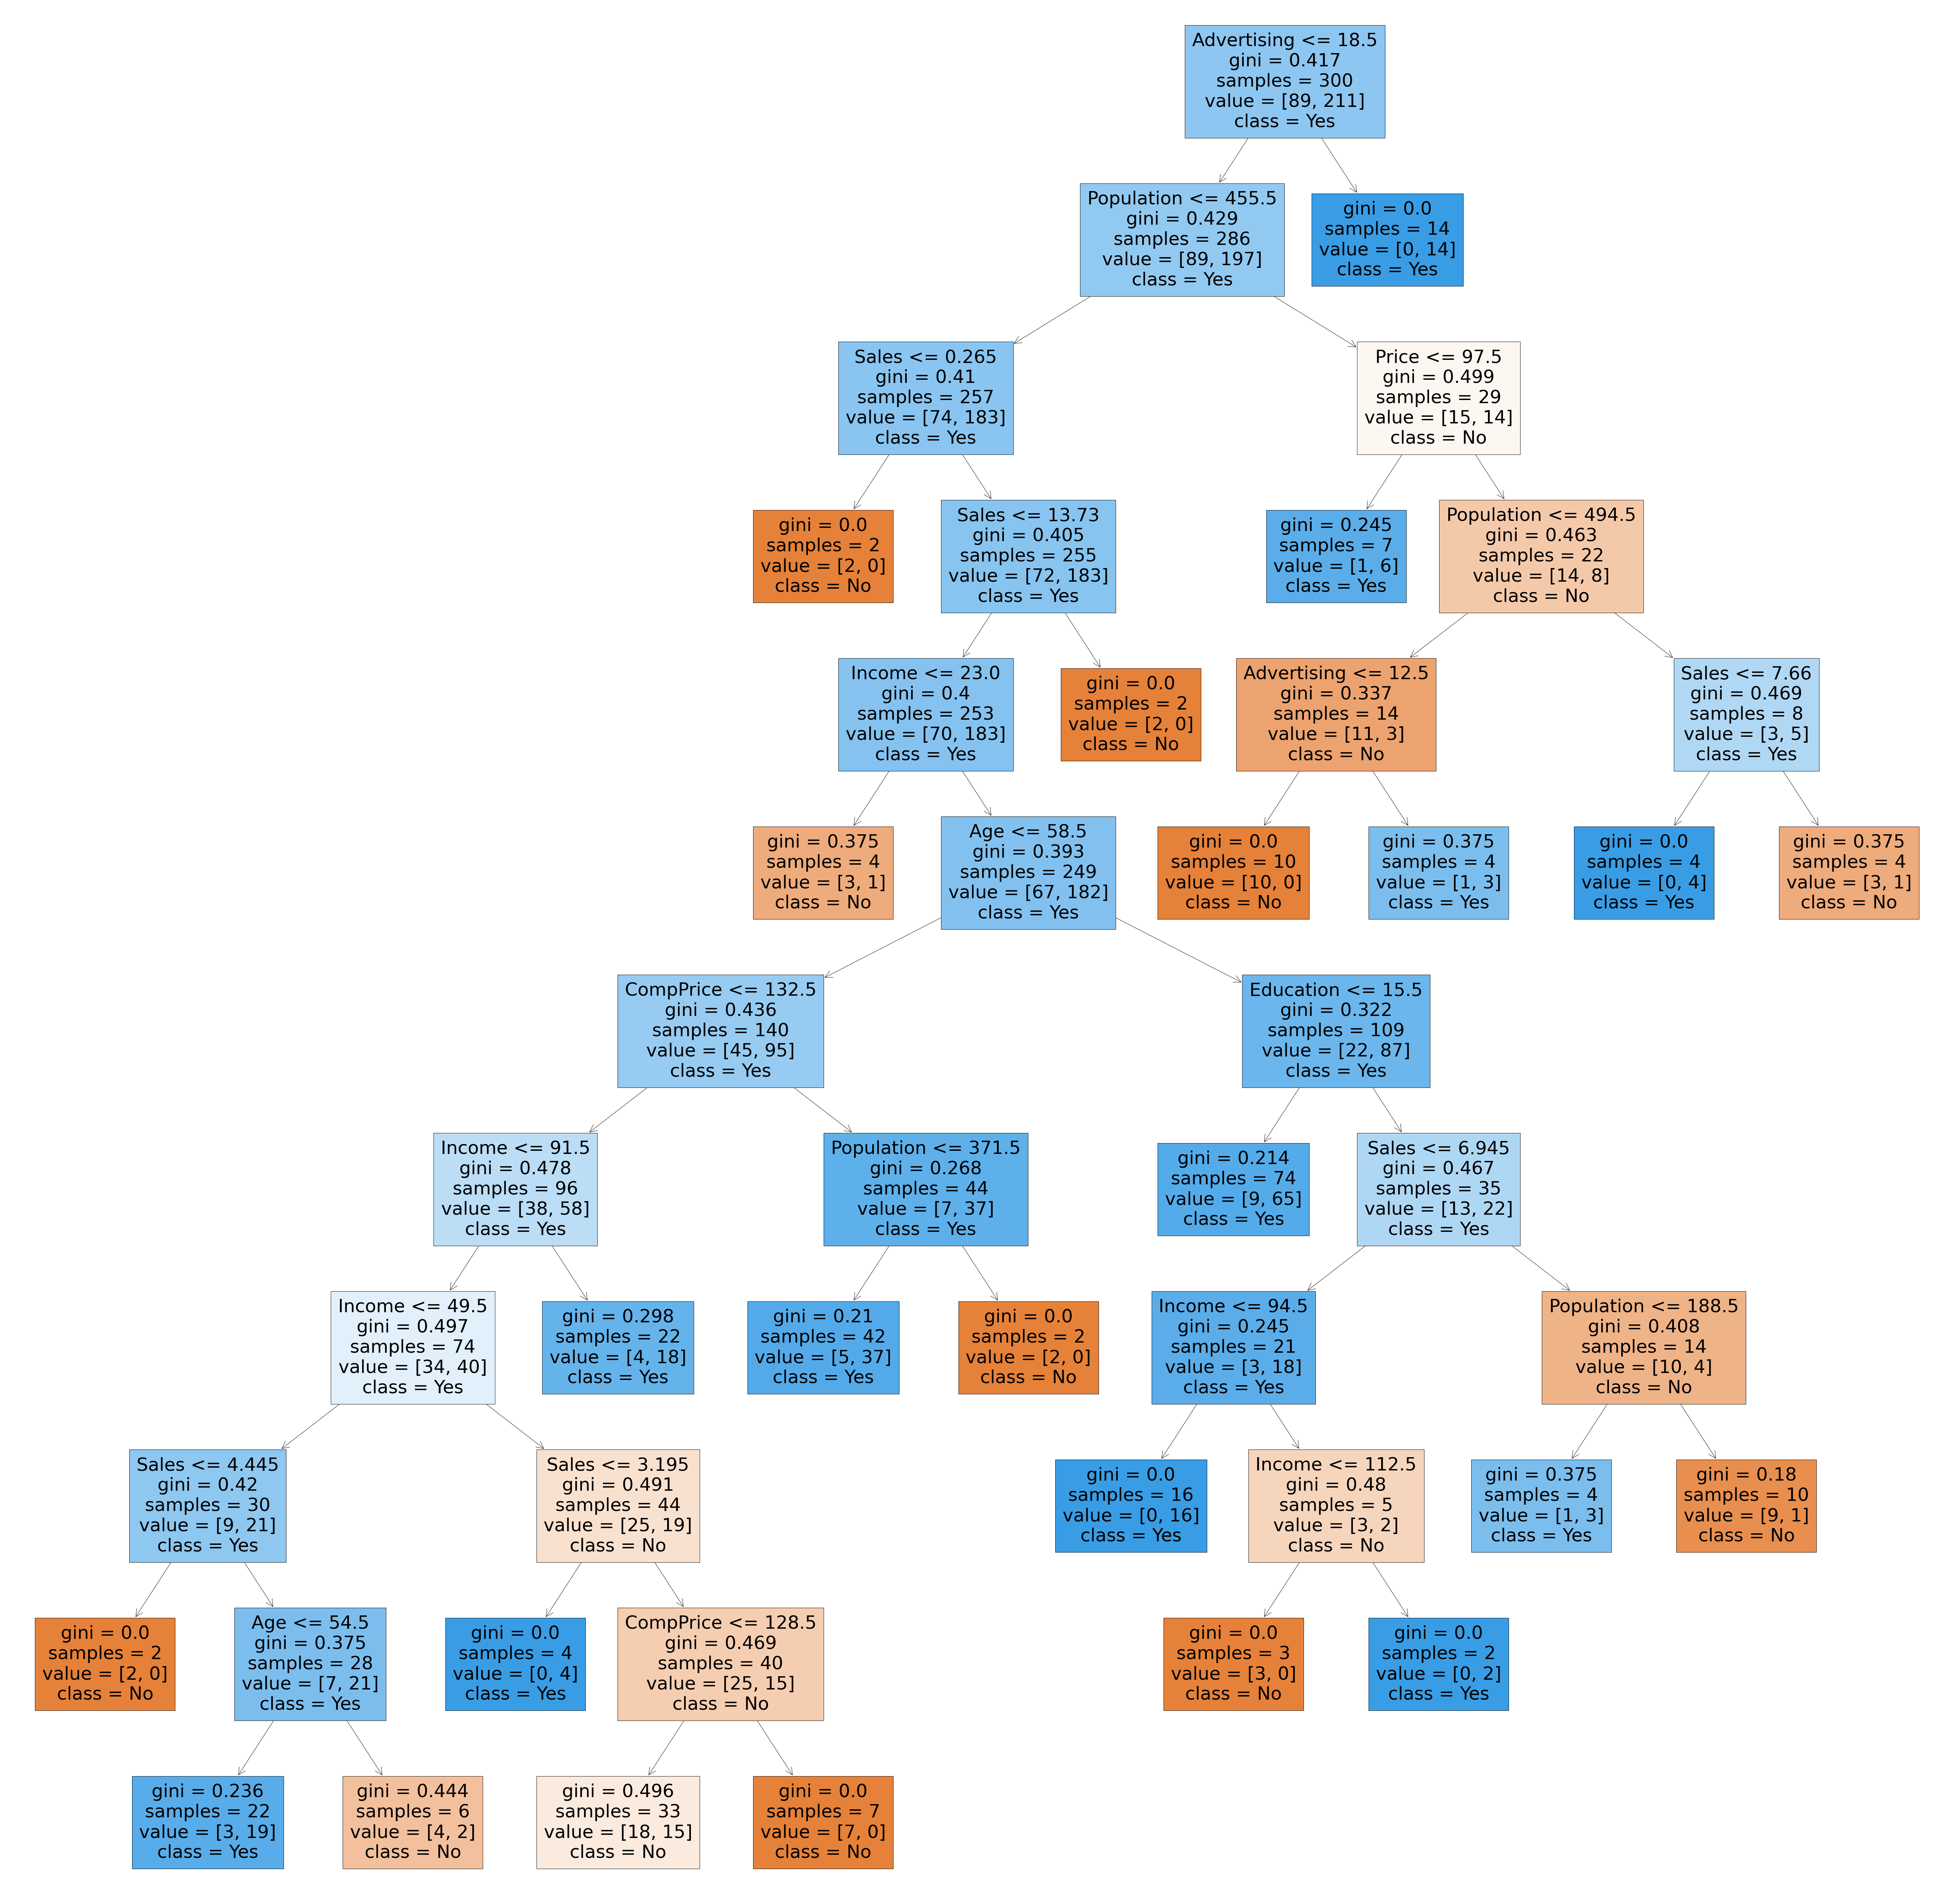

In [42]:
plt.figure(figsize = (100, 100))
features = ["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "ShelveLoc", "Age", "Education"]
classes = ["No", "Yes"]
tree.plot_tree(dTree_CarSeats_PostPruned_Alpha, feature_names = features, class_names = classes, filled = True)
plt.show()